# Diffraction Stripe Angle Extraction â€” Interactive Dev

Paired with `angle_dev.py`.  Edit the `.py` file, re-run any cell â€” `%autoreload 2` reloads without a kernel restart.

**Workflow:**
1. Load data
2. Build shared feature image and inspect preprocessing stages
3. Run ensemble estimator and inspect candidates
4. Tune parameters in `angle_dev.py` and iterate

In [56]:
# Cell 1 â€” bootstrap
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

root = next(p for p in Path(".").resolve().parents if (p / "sim").is_dir())
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

print(f"Project root: {root}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project root: C:\Users\bassd\Research\Drone\tele-img-sim


raw:    (3672, 5496)  [-0.004, 280316.844]
stripe: (3672, 5496)  [0.000, 58849.777]


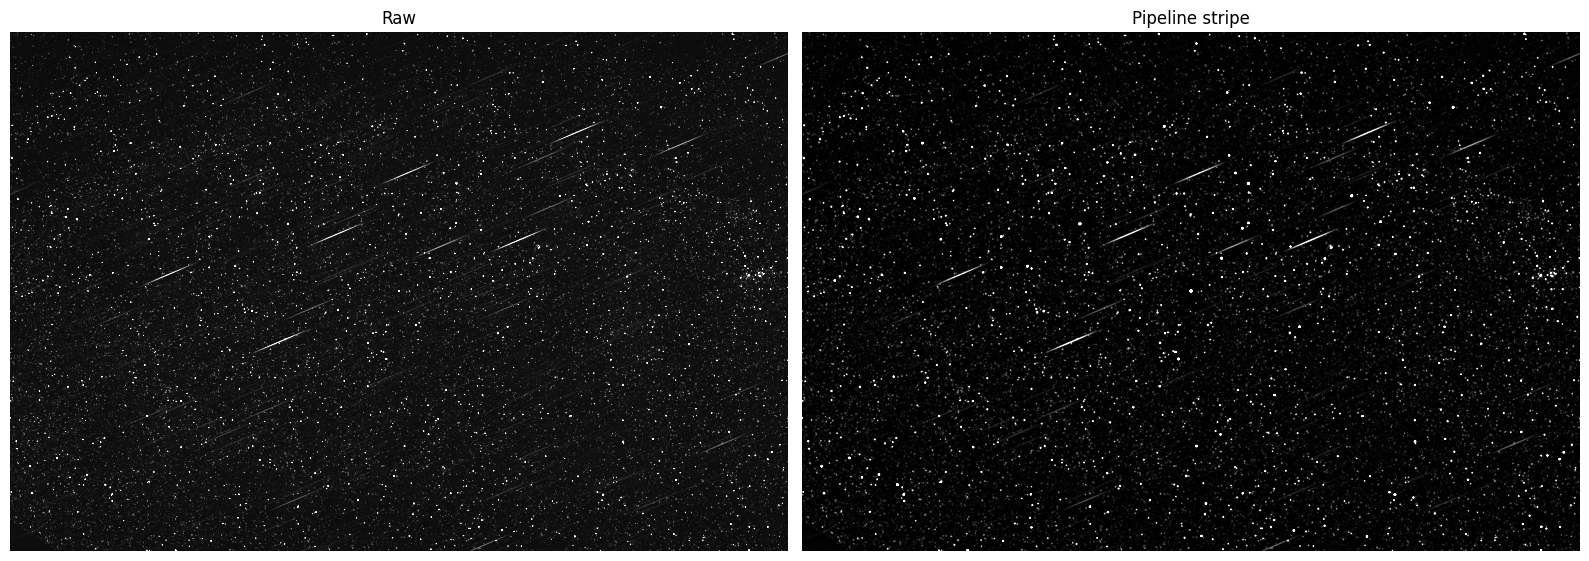

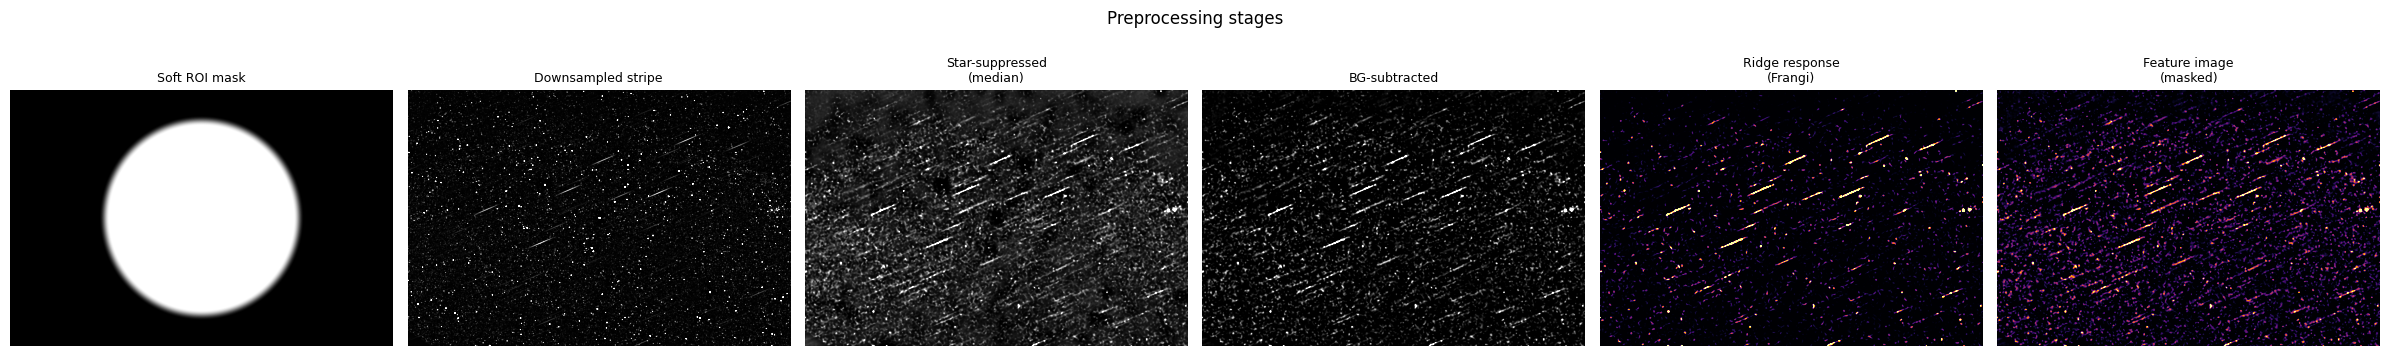

feature_img: (918, 1374)  [0.0000, 72.0209]


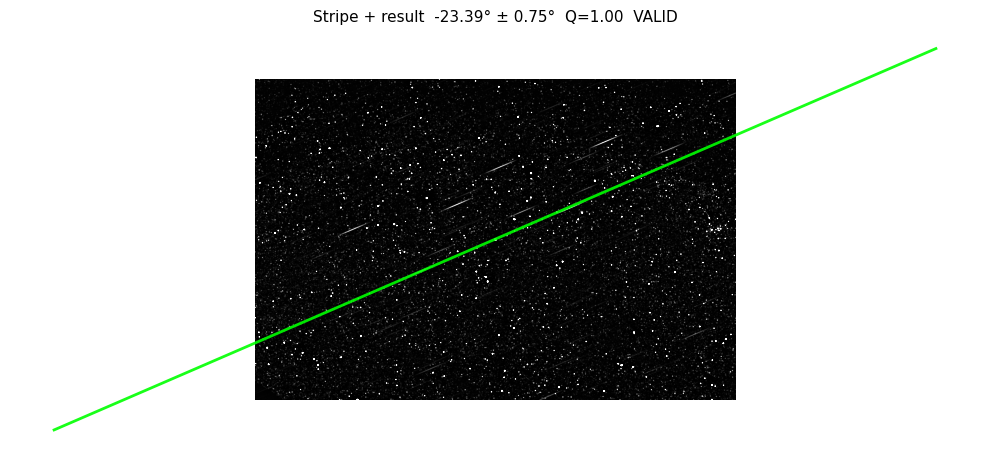

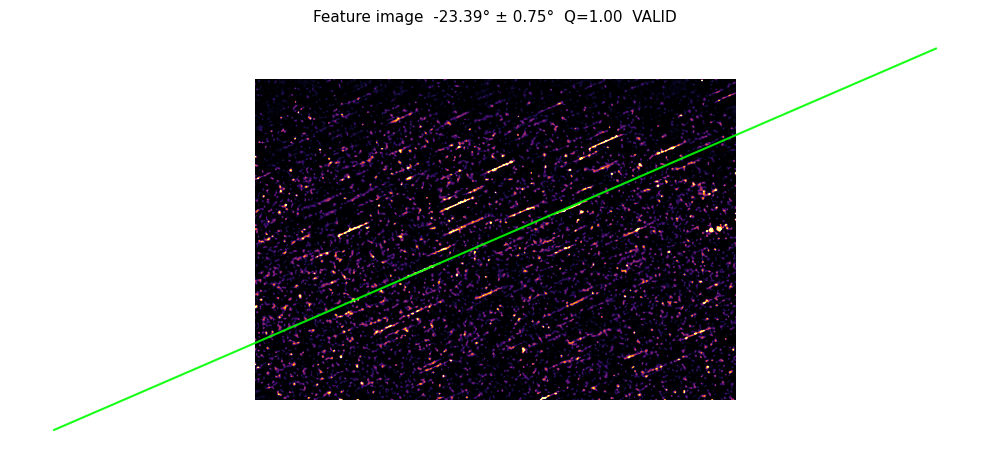

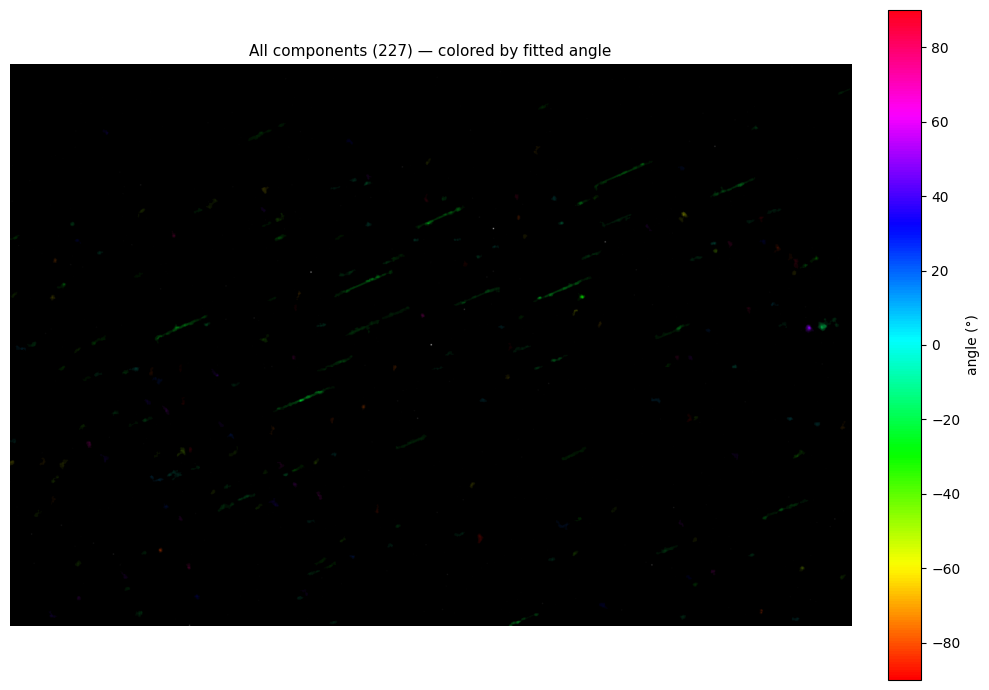

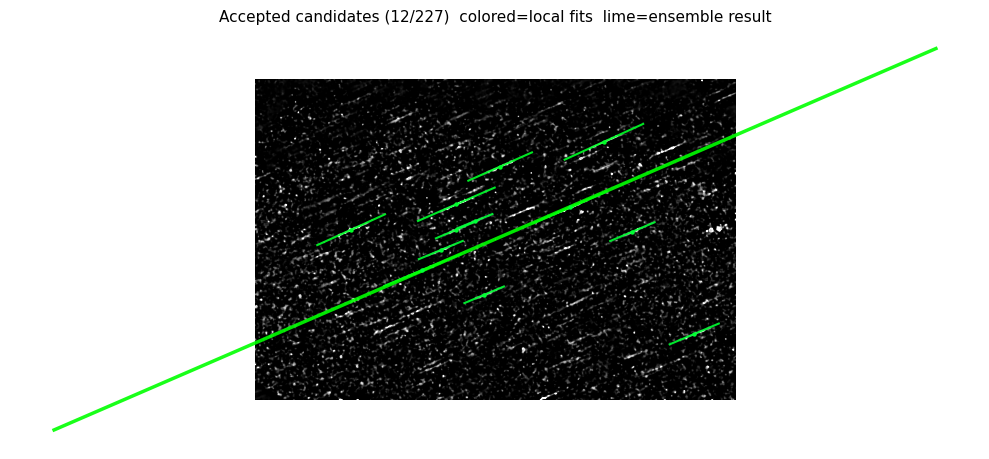

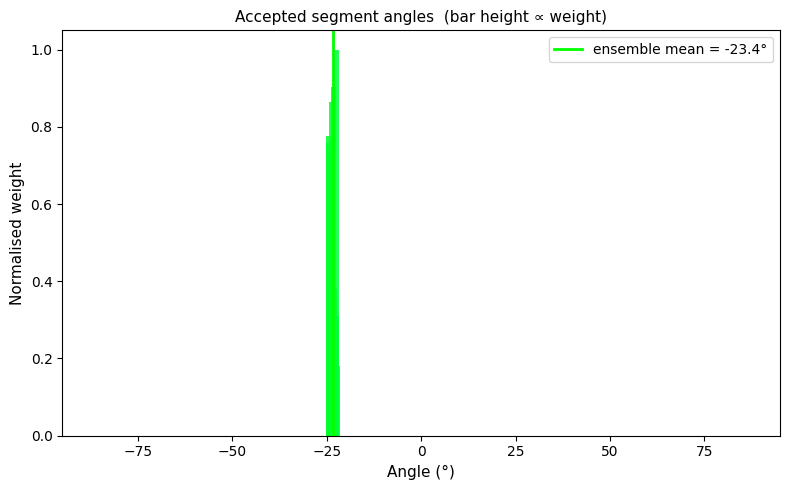

─── Ensemble estimator ───────────────────────────
  Detected components : 227
  Accepted (filtered) : 12
  Filter criteria     : min_major_length=40 px,  min_eccentricity=0.90

  angle   : -23.388 °
  σ       : 0.749 °
  quality : 1.000  (R · scale)
  valid   : YES

  Ensemble spread:
    min=-24.50°  max=-22.10°  raw std=0.73°
──────────────────────────────────────────────────
AngleEstimate(angle_deg=-23.38783967903791, sigma_deg=0.749038792946626, quality=0.9996582170551361, valid=True, method='ensemble')


In [57]:
# Cell 2 â€” load data
import angle_dev
import numpy as np

#FITS_PATH = root / "data" / "fuji6_asi178_100_15s.fit"
FITS_PATH = root / "data" / "testsim.fits"

raw, stripe = angle_dev.load_and_preprocess(FITS_PATH)
print(f"raw:    {raw.shape}  [{raw.min():.3f}, {raw.max():.3f}]")
print(f"stripe: {stripe.shape}  [{stripe.min():.3f}, {stripe.max():.3f}]")

# Cell 3 â€” visualise raw vs pipeline stripe image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, img, title in [(axes[0], raw, "Raw"), (axes[1], stripe, "Pipeline stripe")]:
    finite = img[np.isfinite(img)]
    vmin, vmax = np.percentile(finite, [0.5, 99.5])
    ax.imshow(img, origin="lower", cmap="gray", vmin=vmin, vmax=vmax)
    ax.set_title(title); ax.axis("off")
plt.tight_layout(); plt.show()

# Cell 4 â€” build shared feature image and inspect preprocessing stages
# Tune parameters inside prepare_angle_feature_image() and re-run.
feature_img, dbg = angle_dev.prepare_angle_feature_image(stripe)
angle_dev.show_feature_debug(stripe, dbg)
print(f"feature_img: {feature_img.shape}  [{feature_img.min():.4f}, {feature_img.max():.4f}]")

# Cell 5 â€” run ensemble estimator and inspect
# Tune parameters here (or in measure_ensemble_lines / show_ensemble_debug) and re-run.
# Cell 5 â€” run ensemble estimator and inspect
# Tune parameters here and re-run.

THRESHOLD_PCT    = 90.0   # percentile of nonzero feature values for binary threshold
MIN_PIXELS       = 40     # minimum component size
MIN_MAJOR_LEN    = 40.0   # minimum major axis length (px in feature_img domain)
MIN_ECCENTRICITY = 0.90   # 0=circle, 1=line; reject blobs below this

# New: angle-space outlier rejection
SIGMA_CLIP       = 1.5    # clip candidates farther than N sigma from ensemble angle
CLIP_MAX_ITER    = 3      # max clipping iterations

angle_dev.show_ensemble_debug(
    stripe,
    feature_img,
    dbg,
    threshold_pct=THRESHOLD_PCT,
    min_pixels=MIN_PIXELS,
    min_major_length=MIN_MAJOR_LEN,
    min_eccentricity=MIN_ECCENTRICITY,
    sigma_clip=SIGMA_CLIP,
    clip_max_iter=CLIP_MAX_ITER,
)

est = angle_dev.measure_ensemble_lines(
    feature_img,
    threshold_pct=THRESHOLD_PCT,
    min_pixels=MIN_PIXELS,
    min_major_length=MIN_MAJOR_LEN,
    min_eccentricity=MIN_ECCENTRICITY,
    sigma_clip=SIGMA_CLIP,
    clip_max_iter=CLIP_MAX_ITER,
)

print(est)

raw:    (2080, 3096)  [0.000, 1.000]
stripe: (2080, 3096)  [0.000, 0.710]


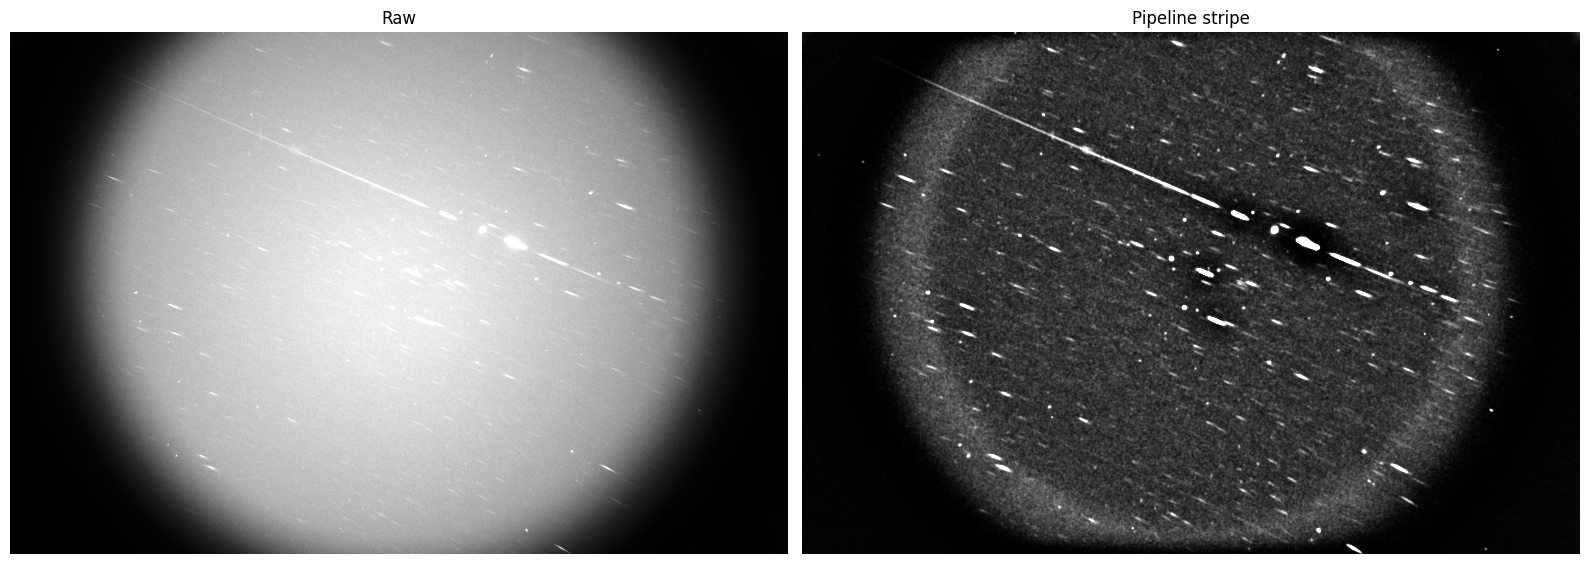

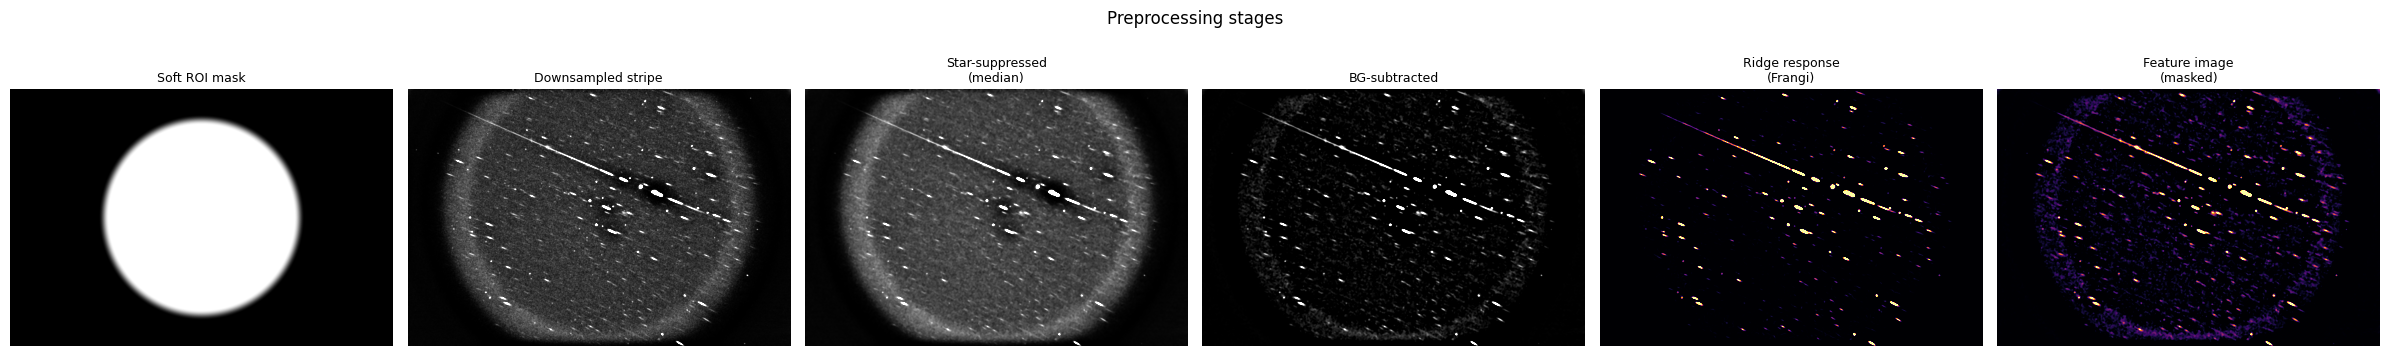

feature_img: (1040, 1548)  [0.0000, 0.5941]


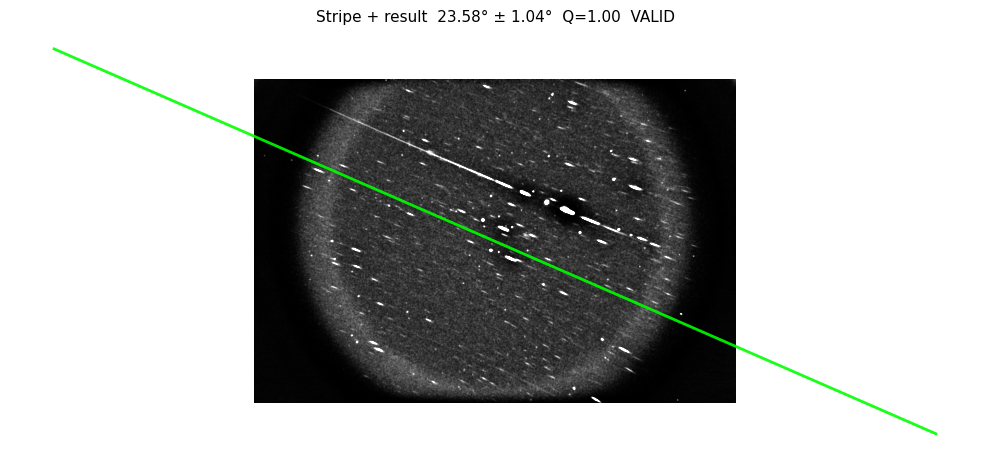

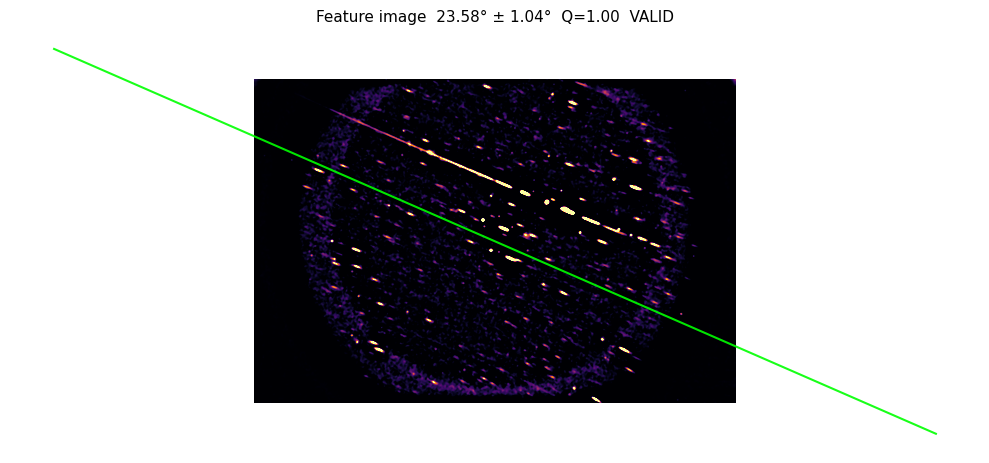

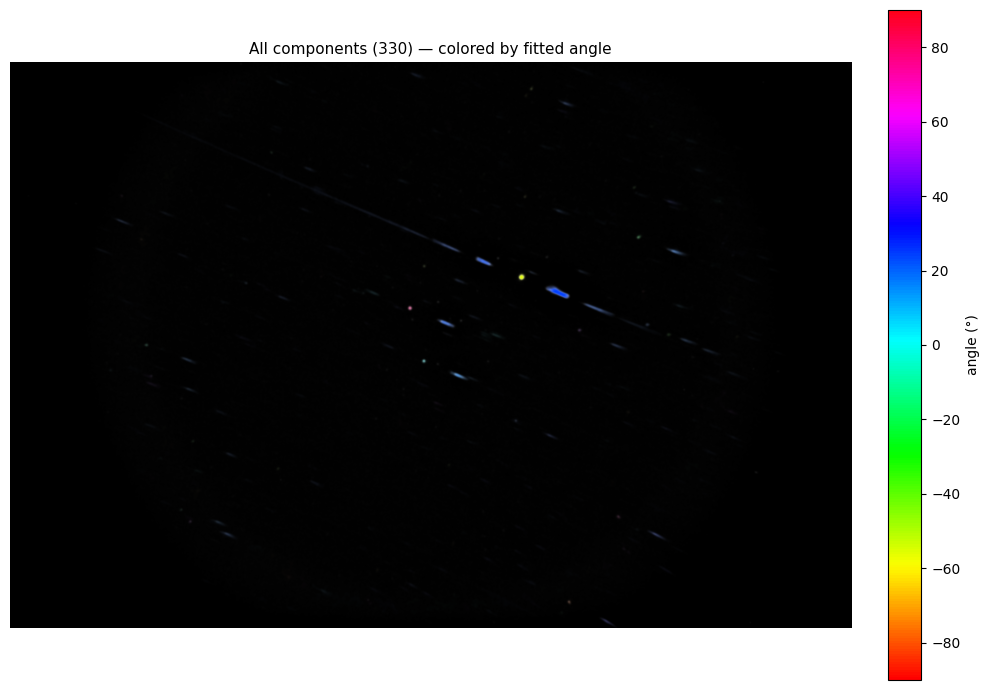

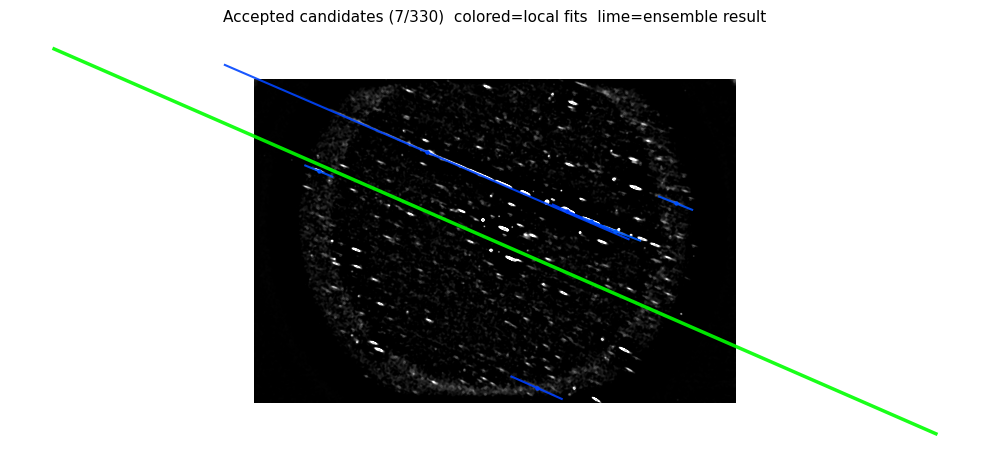

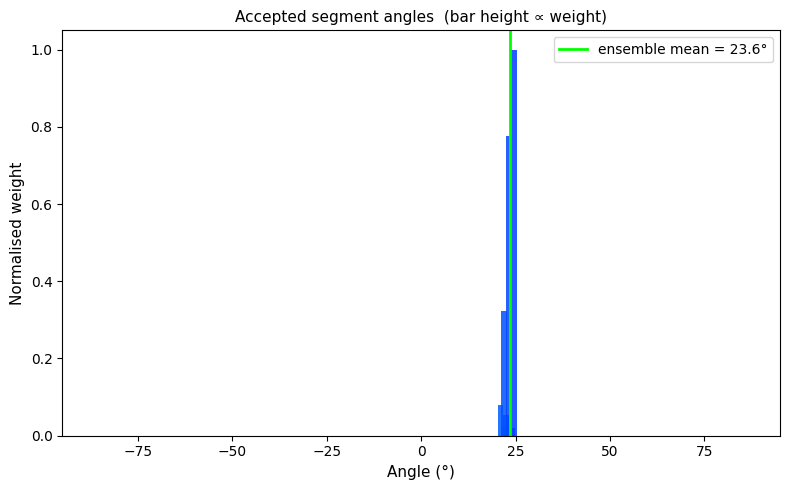

─── Ensemble estimator ───────────────────────────
  Detected components : 330
  Accepted (filtered) : 7
  Filter criteria     : min_major_length=40 px,  min_eccentricity=0.90

  angle   : 23.577 °
  σ       : 1.038 °
  quality : 0.999  (R · scale)
  valid   : YES

  Ensemble spread:
    min=21.02°  max=24.56°  raw std=1.18°
──────────────────────────────────────────────────
AngleEstimate(angle_deg=23.576936173712657, sigma_deg=1.0383902740815008, quality=0.9993432676950481, valid=True, method='ensemble')


In [58]:
# Cell 2 â€” load data
import angle_dev
import numpy as np

FITS_PATH = root / "data" / "fuji6_asi178_100_15s.fit"
#FITS_PATH = root / "data" / "testsim.fits"

raw, stripe = angle_dev.load_and_preprocess(FITS_PATH)
print(f"raw:    {raw.shape}  [{raw.min():.3f}, {raw.max():.3f}]")
print(f"stripe: {stripe.shape}  [{stripe.min():.3f}, {stripe.max():.3f}]")

# Cell 3 â€” visualise raw vs pipeline stripe image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, img, title in [(axes[0], raw, "Raw"), (axes[1], stripe, "Pipeline stripe")]:
    finite = img[np.isfinite(img)]
    vmin, vmax = np.percentile(finite, [0.5, 99.5])
    ax.imshow(img, origin="lower", cmap="gray", vmin=vmin, vmax=vmax)
    ax.set_title(title); ax.axis("off")
plt.tight_layout(); plt.show()

# Cell 4 â€” build shared feature image and inspect preprocessing stages
# Tune parameters inside prepare_angle_feature_image() and re-run.
feature_img, dbg = angle_dev.prepare_angle_feature_image(stripe)
angle_dev.show_feature_debug(stripe, dbg)
print(f"feature_img: {feature_img.shape}  [{feature_img.min():.4f}, {feature_img.max():.4f}]")

# Cell 5 â€” run ensemble estimator and inspect
# Tune parameters here (or in measure_ensemble_lines / show_ensemble_debug) and re-run.
# Cell 5 â€” run ensemble estimator and inspect
# Tune parameters here and re-run.

THRESHOLD_PCT    = 90.0   # percentile of nonzero feature values for binary threshold
MIN_PIXELS       = 40     # minimum component size
MIN_MAJOR_LEN    = 40.0   # minimum major axis length (px in feature_img domain)
MIN_ECCENTRICITY = 0.90   # 0=circle, 1=line; reject blobs below this

# New: angle-space outlier rejection
SIGMA_CLIP       = 1.5    # clip candidates farther than N sigma from ensemble angle
CLIP_MAX_ITER    = 3      # max clipping iterations

angle_dev.show_ensemble_debug(
    stripe,
    feature_img,
    dbg,
    threshold_pct=THRESHOLD_PCT,
    min_pixels=MIN_PIXELS,
    min_major_length=MIN_MAJOR_LEN,
    min_eccentricity=MIN_ECCENTRICITY,
    sigma_clip=SIGMA_CLIP,
    clip_max_iter=CLIP_MAX_ITER,
)

est = angle_dev.measure_ensemble_lines(
    feature_img,
    threshold_pct=THRESHOLD_PCT,
    min_pixels=MIN_PIXELS,
    min_major_length=MIN_MAJOR_LEN,
    min_eccentricity=MIN_ECCENTRICITY,
    sigma_clip=SIGMA_CLIP,
    clip_max_iter=CLIP_MAX_ITER,
)

print(est)

## Tuning guide

| Parameter | Effect | Tune when... |
|---|---|---|
| `THRESHOLD_PCT` | Controls which pixels enter components | Too many noise components â†’ raise; stripe missed â†’ lower |
| `MIN_PIXELS` | Minimum component size | Many tiny noise blobs â†’ raise |
| `MIN_MAJOR_LEN` | Minimum segment length | Short spurious segments â†’ raise |
| `MIN_ECCENTRICITY` | How elongated a segment must be (0â€“1) | Blobs contaminating result â†’ raise |
| `ridge_sigmas` in `prepare_angle_feature_image` | Frangi scales (px) | Stripe not detected â†’ bracket the expected stripe width |

## Next step: move to `measure/spikes.py` and `measure/preprocess.py`

Once results look correct:
1. `prepare_angle_feature_image` + helpers â†’ `measure/preprocess.py`
2. `_extract_candidates`, `_filter_candidates`, `_weighted_axial_mean`, `_weighted_angle_sigma`, `measure_ensemble_lines` â†’ `measure/spikes.py`
3. Replace `_measure_radon` / `_measure_hough` / `_measure_fourier` stubs with the ensemble approach
4. Run `measurement.ipynb` end-to-end to verify `SpikeMeasurementResult.image_angle_deg` is non-zero

## Part A — Parameter Sweep

Sweep `threshold_pct`, `min_pixels`, `min_major_length`, and `min_eccentricity` to find the best-performing combination. Results are ranked by a composite score: `quality × √n_accepted / (σ + 0.5)`.

In [59]:
# Cell A1 — define parameter grids (edit these before sweeping)
# More grid points = finer sweep; extraction is cached per (threshold, min_pixels)
# so only threshold × min_pixels calls are expensive.
SWEEP_THRESHOLD_PCTS     = (65.0, 68.0, 71.0, 74.0, 77.0, 80.0, 83.0, 86.0, 89.0, 92.0, 95.0)
SWEEP_MIN_PIXELS         = (15, 25, 35, 50, 65, 80)
SWEEP_MIN_MAJOR_LENGTHS  = (10.0, 15.0, 20.0, 28.0, 38.0, 52.0)
SWEEP_MIN_ECCENTRICITIES = (0.75, 0.79, 0.83, 0.86, 0.89, 0.92, 0.95)
SWEEP_MIN_ACCEPTED       = 3   # minimum n_accepted to be ranked

n_extraction_calls = len(SWEEP_THRESHOLD_PCTS) * len(SWEEP_MIN_PIXELS)
n_combos = (len(SWEEP_THRESHOLD_PCTS) * len(SWEEP_MIN_PIXELS)
            * len(SWEEP_MIN_MAJOR_LENGTHS) * len(SWEEP_MIN_ECCENTRICITIES))
print(f"Grid: {len(SWEEP_THRESHOLD_PCTS)}×{len(SWEEP_MIN_PIXELS)}×{len(SWEEP_MIN_MAJOR_LENGTHS)}×{len(SWEEP_MIN_ECCENTRICITIES)} = {n_combos} combinations")
print(f"Cached extraction calls: {n_extraction_calls}")


Grid: 11×6×6×7 = 2772 combinations
Cached extraction calls: 66


In [60]:
# Cell A2 — run sweep (uses cached extraction; takes a few seconds)
sweep_results = angle_dev.sweep_ensemble_params(
    feature_img,
    threshold_pcts=SWEEP_THRESHOLD_PCTS,
    min_pixels_vals=SWEEP_MIN_PIXELS,
    min_major_lengths=SWEEP_MIN_MAJOR_LENGTHS,
    min_eccentricities=SWEEP_MIN_ECCENTRICITIES,
    min_accepted_for_ranking=SWEEP_MIN_ACCEPTED,
    verbose=True,
)


Sweeping 2772 combinations (11×6×6×7)…
Done.  2772/2772 valid.  Best score: 2.618  → angle=22.33°  σ=4.10°


In [61]:
# Cell A3 — display top results
SHOW_TOP_N = 25
angle_dev.print_sweep_results(sweep_results, top_n=SHOW_TOP_N)


  #   thr  mpx  mlen  mecc    angle   sigma   qual  V  nacc  ndet  acc%    score
────────────────────────────────────────────────────────────────────────────────
  1    95   15    10  0.86    22.33   4.100  0.990  Y   148   279  53.0    2.618
  2    95   25    10  0.86    22.33   4.100  0.990  Y   147   222  66.2    2.609
  3    95   15    10  0.89    22.32   4.030  0.990  Y   140   279  50.2    2.587
  4    95   25    10  0.89    22.31   4.029  0.990  Y   139   222  62.6    2.578
  5    95   35    10  0.86    22.33   4.103  0.990  Y   143   187  76.5    2.572
  6    95   35    10  0.89    22.31   4.032  0.990  Y   135   187  72.2    2.539
  7    95   15    10  0.92    22.31   3.972  0.991  Y   131   279  47.0    2.535
  8    95   25    10  0.92    22.30   3.972  0.991  Y   130   222  58.6    2.526
  9    95   50    10  0.86    22.31   3.986  0.990  Y   130   154  84.4    2.517
 10    95   50    10  0.89    22.30   3.913  0.991  Y   125   154  81.2    2.510
 11    95   35    10  0.92  

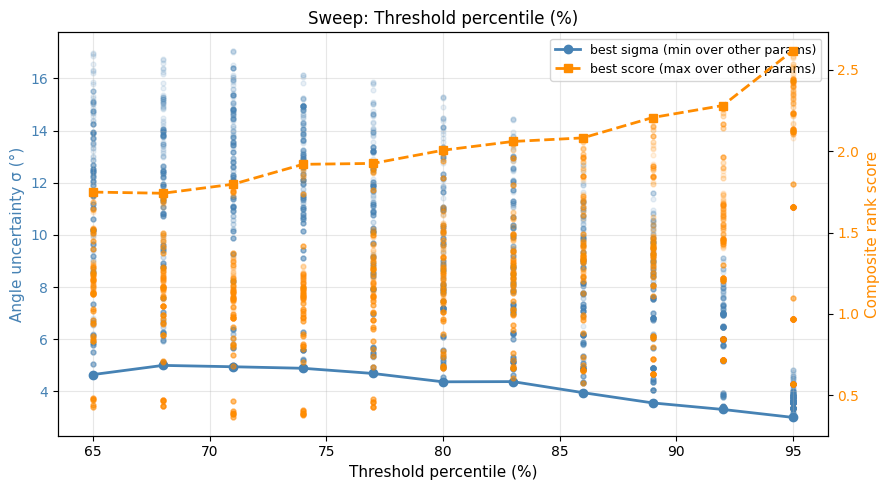

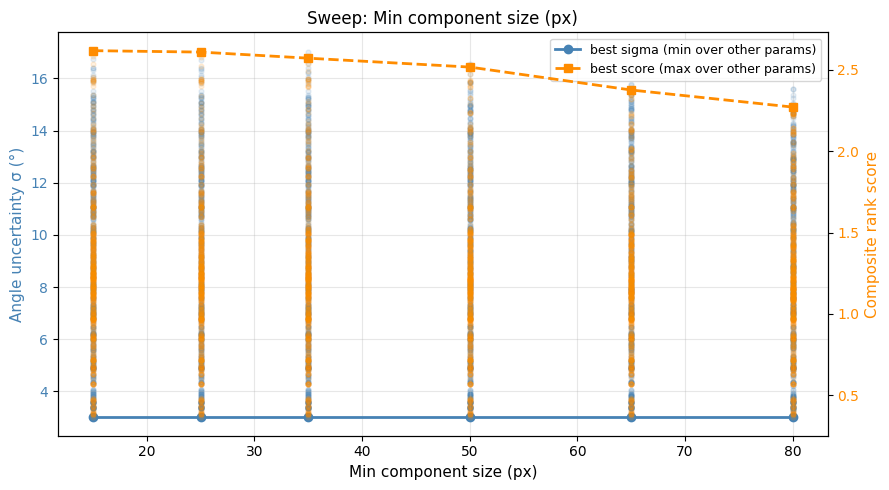

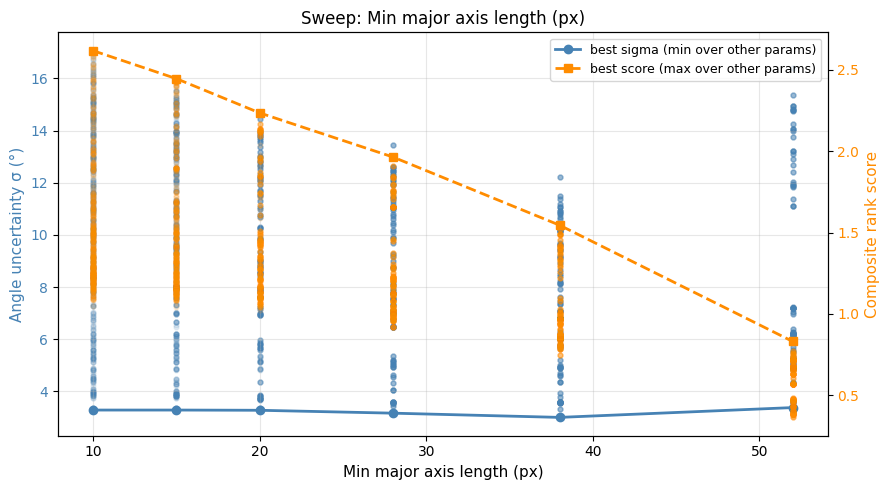

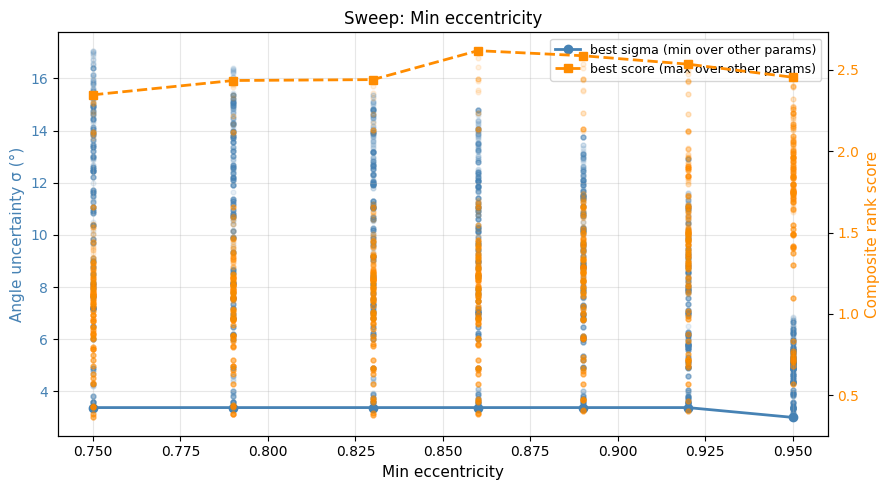


Total valid combinations: 2772 / 2772


In [62]:
# Cell A3b — sweep diagnostic plots
# For each of the four parameters, shows how sigma and composite score
# vary as that parameter changes (collapsing the other three by taking the
# best-scoring result and the median across all other combinations).
#
# Left y-axis  (blue)  : angle uncertainty sigma_deg
# Right y-axis (orange): composite rank_score
# Solid line = best result (min sigma / max score) per parameter value
# Faint scatter = all valid results for that parameter value

import matplotlib.pyplot as plt
import numpy as np

params = [
    ("threshold_pct",    "Threshold percentile (%)",      SWEEP_THRESHOLD_PCTS),
    ("min_pixels",       "Min component size (px)",        SWEEP_MIN_PIXELS),
    ("min_major_length", "Min major axis length (px)",     SWEEP_MIN_MAJOR_LENGTHS),
    ("min_eccentricity", "Min eccentricity",               SWEEP_MIN_ECCENTRICITIES),
]

valid_rows = [r for r in sweep_results if r['valid'] and r['rank_score'] > 0]
all_rows   = sweep_results  # include invalid for scatter context

for param_key, xlabel, grid_vals in params:
    fig, ax1 = plt.subplots(figsize=(9, 5))
    ax2 = ax1.twinx()

    # Scatter of ALL valid rows (faint) for this parameter axis
    xs_all   = [r[param_key] for r in valid_rows]
    sig_all  = [r['sigma_deg'] for r in valid_rows]
    sc_all   = [r['rank_score'] for r in valid_rows]
    ax1.scatter(xs_all, sig_all,  color='steelblue',  alpha=0.12, s=12, zorder=1)
    ax2.scatter(xs_all, sc_all,   color='darkorange',  alpha=0.12, s=12, zorder=1)

    # Best-per-value lines
    best_sigma = []  # min sigma across other params
    best_score = []  # max score across other params
    for v in grid_vals:
        subset = [r for r in valid_rows if r[param_key] == v]
        if subset:
            best_sigma.append(min(r['sigma_deg']   for r in subset))
            best_score.append(max(r['rank_score']  for r in subset))
        else:
            best_sigma.append(float('nan'))
            best_score.append(float('nan'))

    ax1.plot(grid_vals, best_sigma, 'o-',  color='steelblue',  lw=2,   zorder=3,
             label='best sigma (min over other params)')
    ax2.plot(grid_vals, best_score, 's--', color='darkorange', lw=2,   zorder=3,
             label='best score (max over other params)')

    ax1.set_xlabel(xlabel, fontsize=11)
    ax1.set_ylabel("Angle uncertainty σ (°)", color='steelblue', fontsize=11)
    ax2.set_ylabel("Composite rank score", color='darkorange', fontsize=11)
    ax1.tick_params(axis='y', labelcolor='steelblue')
    ax2.tick_params(axis='y', labelcolor='darkorange')

    # Combined legend
    lines1, labs1 = ax1.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labs1 + labs2, fontsize=9, loc='upper right')

    ax1.set_title(f'Sweep: {xlabel}', fontsize=12)
    ax1.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print(f"\nTotal valid combinations: {len(valid_rows)} / {len(sweep_results)}")


Chosen params:  threshold=95.0%  min_pixels=15  min_major_length=10.0  min_eccentricity=0.86
Result:         angle=22.331°  σ=4.100°  quality=0.990  n_accepted=148


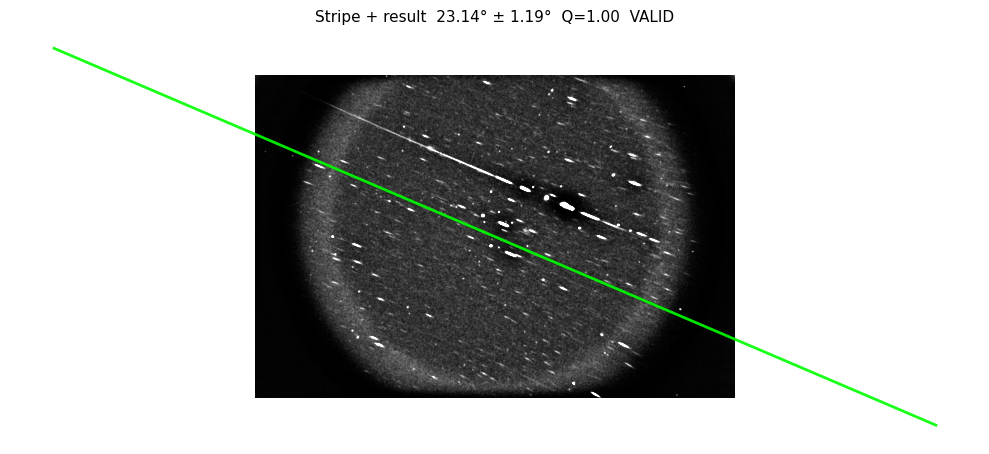

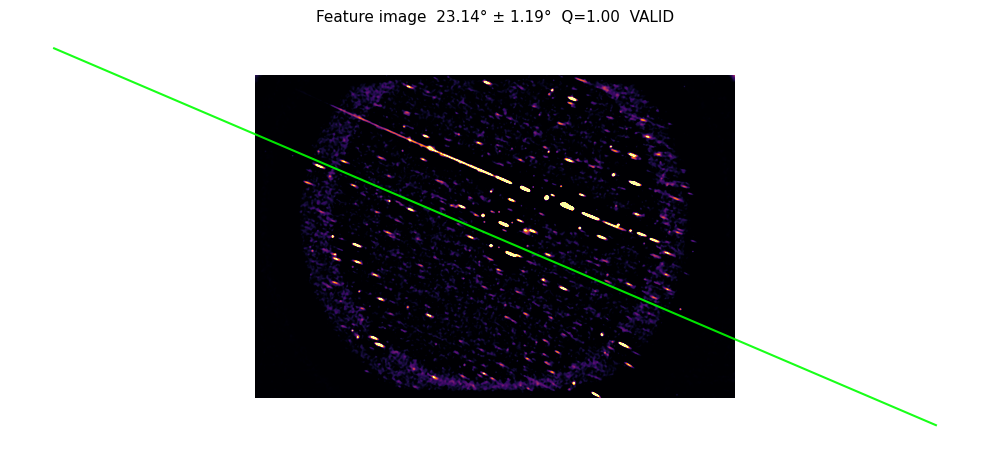

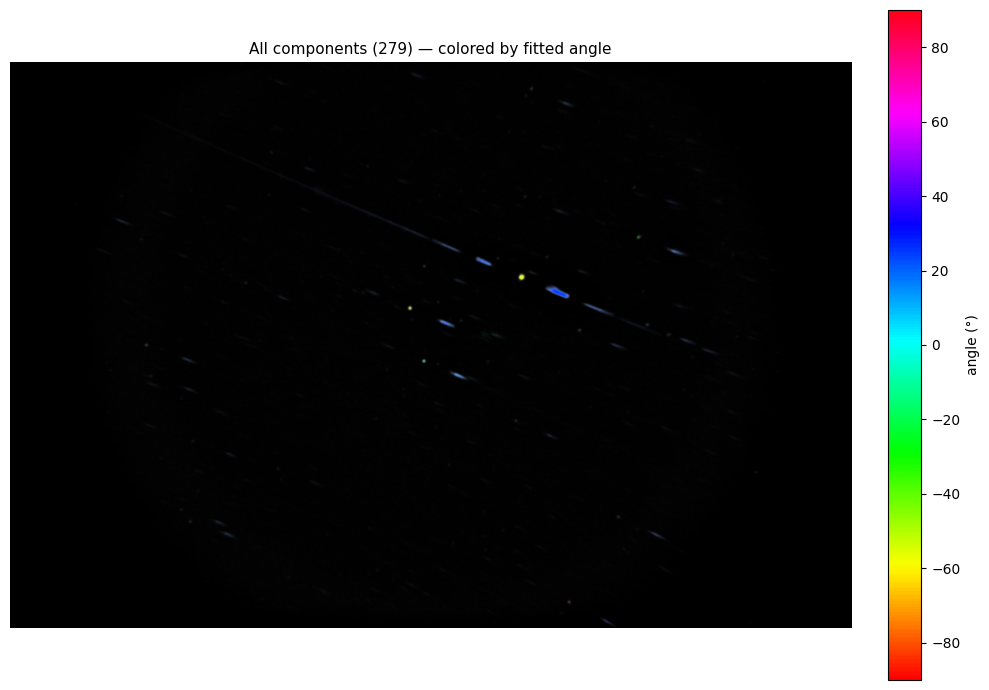

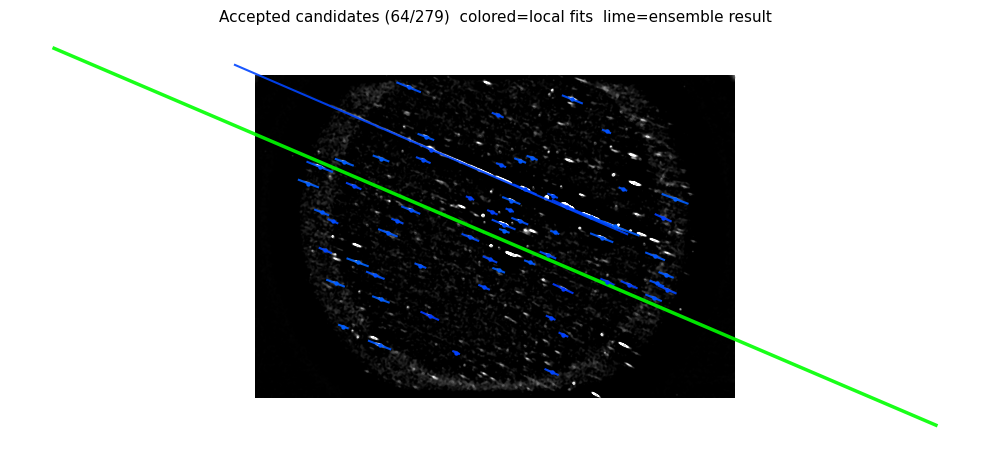

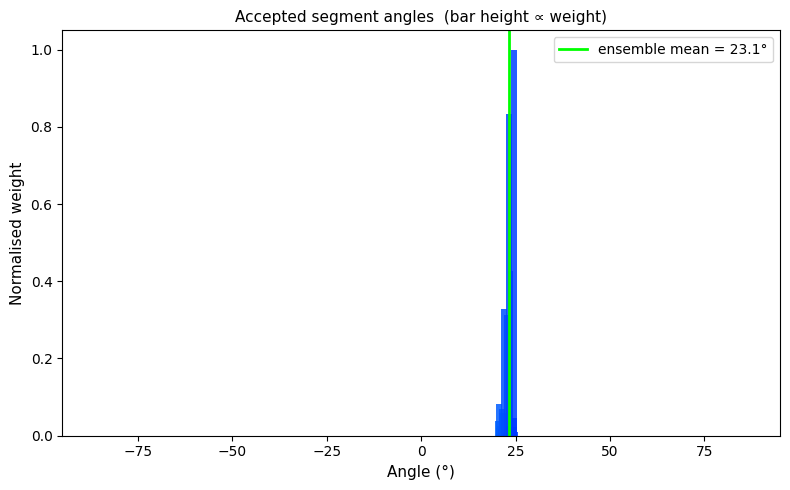

─── Ensemble estimator ───────────────────────────
  Detected components : 279
  Accepted (filtered) : 64
  Filter criteria     : min_major_length=10 px,  min_eccentricity=0.86

  angle   : 23.139 °
  σ       : 1.190 °
  quality : 0.999  (R · scale)
  valid   : YES

  Ensemble spread:
    min=20.37°  max=24.87°  raw std=1.29°
──────────────────────────────────────────────────


In [63]:
# Cell A4 — pick a row and inspect with full debug plots
# Set CHOSEN_ROW to the rank number from the table above (1-indexed).
CHOSEN_ROW = 1

chosen = sweep_results[CHOSEN_ROW - 1]
print(
    f"Chosen params:  threshold={chosen['threshold_pct']}%  "
    f"min_pixels={chosen['min_pixels']}  "
    f"min_major_length={chosen['min_major_length']}  "
    f"min_eccentricity={chosen['min_eccentricity']}\n"
    f"Result:         angle={chosen['angle_deg']:.3f}°  "
    f"σ={chosen['sigma_deg']:.3f}°  "
    f"quality={chosen['quality']:.3f}  n_accepted={chosen['n_accepted']}"
)

angle_dev.show_ensemble_debug(
    stripe,
    feature_img,
    dbg,
    threshold_pct=chosen['threshold_pct'],
    min_pixels=chosen['min_pixels'],
    min_major_length=chosen['min_major_length'],
    min_eccentricity=chosen['min_eccentricity'],
    sigma_clip=SIGMA_CLIP,
    clip_max_iter=CLIP_MAX_ITER,
)


## Part B — Field Angle Variation

Analyse whether locally-fitted angles vary systematically across the field (lens distortion, field curvature, grating tilt). Uses the `chosen` parameter set from Part A, or override the params manually below.

In [53]:
# Cell B1 — run field angle analysis
# Uses the chosen sweep result; override params here if desired.
FIELD_THRESHOLD_PCT    = chosen['threshold_pct']
FIELD_MIN_PIXELS       = chosen['min_pixels']
FIELD_MIN_MAJOR_LENGTH = chosen['min_major_length']
FIELD_MIN_ECCENTRICITY = chosen['min_eccentricity']

field_data, field_est = angle_dev.analyze_field_angle_variation(
    feature_img,
    threshold_pct=FIELD_THRESHOLD_PCT,
    min_pixels=FIELD_MIN_PIXELS,
    min_major_length=FIELD_MIN_MAJOR_LENGTH,
    min_eccentricity=FIELD_MIN_ECCENTRICITY,
)

print(f"Global estimate : {field_est.angle_deg:.3f}° ± {field_est.sigma_deg:.3f}°  "
      f"(quality={field_est.quality:.3f}, valid={field_est.valid})")
print(f"Candidates used : {len(field_data)}")


Global estimate : 22.584° ± 2.461°  (quality=0.996, valid=True)
Candidates used : 84


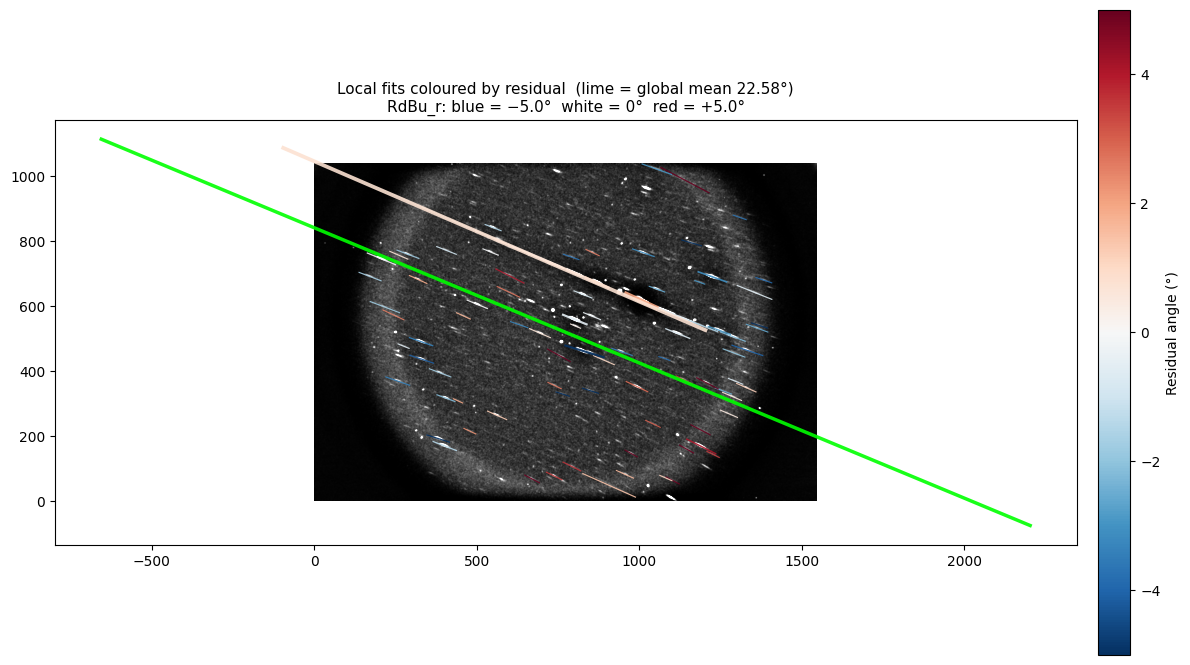

In [54]:
# Cell B2 — spatial overlay coloured by residual angle
# Uses the downsampled image as background for a natural look.
RESIDUAL_VMAX = 5.0   # colour scale ±limit in degrees

angle_dev.show_field_angle_overlay(
    feature_img,
    field_data,
    est=field_est,
    background=dbg["downsampled"],
    residual_vmax=RESIDUAL_VMAX,
)


Residual vs X :  slope=+0.3284 °/unit   r=+0.0695


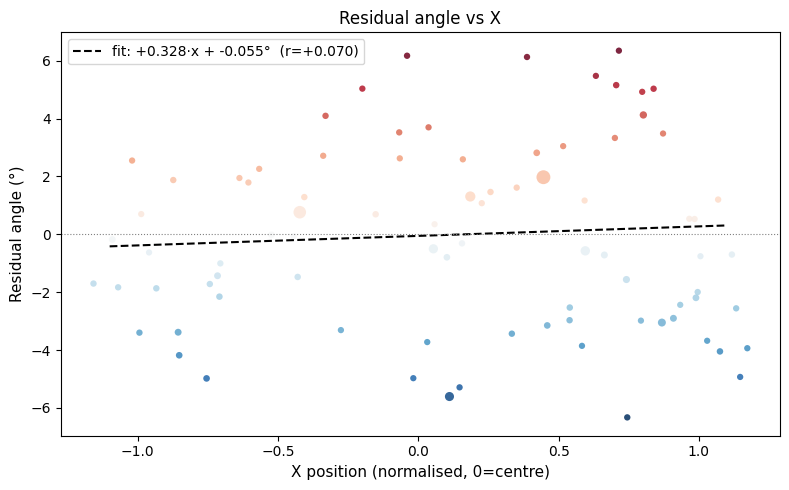

Residual vs Y :  slope=-0.5967 °/unit   r=-0.0797


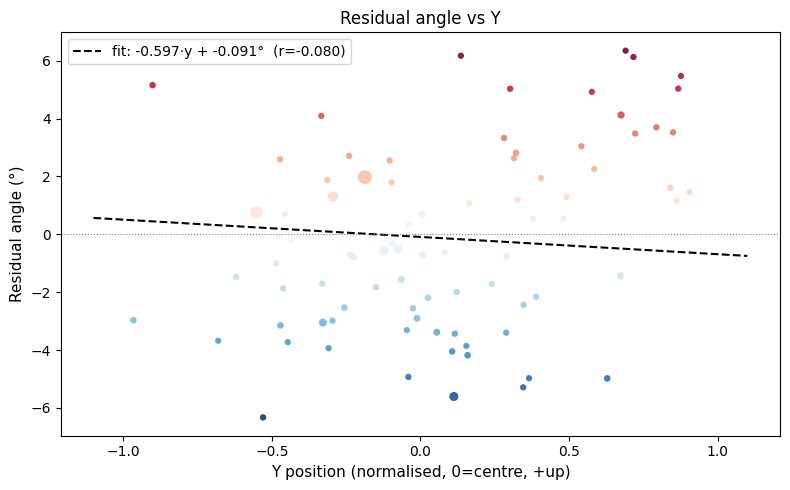

Residual vs R :  slope=+0.2641 °/unit   r=+0.0304


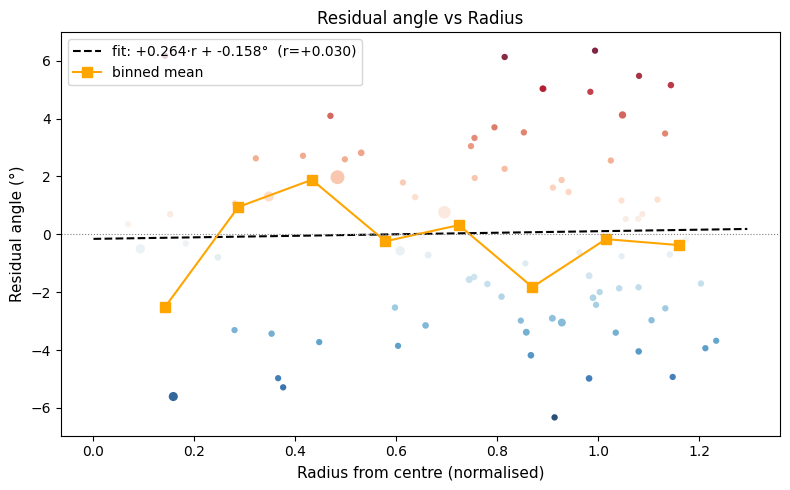

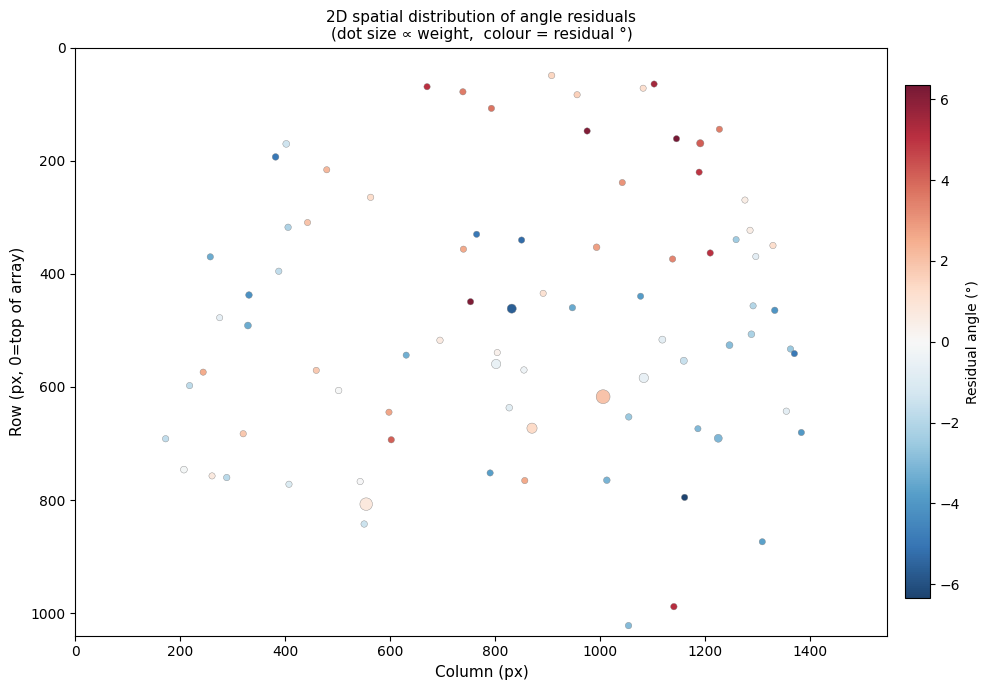


Field variation summary (84 accepted candidates):
  residual range:  [-6.32°, 6.34°]
  weighted rms:    2.461°


In [55]:
# Cell B3 — residual trend plots (vs X, Y, radius, 2D scatter)
angle_dev.show_field_angle_trends(
    field_data,
    feature_img_shape=feature_img.shape,
)
